# Plots for case study

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, colors, ticker
import matplotlib.dates as mdates
from scipy.interpolate import interp2d, RectBivariateSpline
from datetime import datetime, timedelta
import pandas as pd
import cftime
import seaborn as sns
import json
from matplotlib import rc
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap,Normalize
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
#import cmweather
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import glob
import os

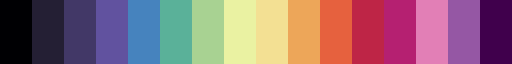

In [3]:
# Load colormap

# Read the colormap from a .txt file
def load_colormap_from_txt(file_path):
    # Load RGB values from the file
    rgb_values = np.loadtxt(file_path)
    return ListedColormap(rgb_values)

# Example usage
colormap_file = 'chase-spectral-rgb.txt'  # Replace with your .txt file path
radar_cmap = load_colormap_from_txt(colormap_file)

discrete_cmap = ListedColormap(radar_cmap(np.linspace(0, 1, 16)))
discrete_mask_cmap = discrete_cmap.copy()
discrete_mask_cmap.set_under(color='white') #set values below vmin to white
discrete_mask_cmap.set_bad(color='gray') #set missing (NaN) values to gray

discrete_mask_cmap

Define time period of case study

In [4]:
#Define time period
time1 = np.datetime64('2024-09-08T08:00')
time2 = np.datetime64('2024-09-08T14:00')

time_map1 = np.datetime64('2024-09-08T11:00')
time_map2 = np.datetime64('2024-09-08T12:00')

time_RHI = np.datetime64('2024-09-08T11:08:24.192') #start time for (real-time 278 = corrected 294.3 azimuth at 11:08
#time_RHI = np.datetime64('2024-09-03T16:09')
az_RHI = 294.3
#az_RHI = 187.0
#RHI_fname = '/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_rhi_2D.nc'
#RHI_fname= '/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4a/rhi/20240908/gridded_rhi_20240908_1108_278.0.nc' #start = 2024-09-08T11:08:24.192
#RHI_fname = '/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4a/rhi/20240903/gridded_rhi_20240903_1609_187.0.nc'

QVP 1D data

In [5]:
# load data
#qvp = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_qvp_1D.nc')
qvp = xr.open_dataset("ipfs://bafybeifhwxvq4kh66dry6wo4s7auvdbfhur4gtmhwonw6ru2w537j53xiy", engine="zarr")

#Find indices for start and end times
index1qvp = np.abs(pd.to_datetime(qvp.time) - time1).argmin()
index2qvp = np.abs(pd.to_datetime(qvp.time) - time2).argmin()

#Set missing data to NaN
qvp_DBZ = qvp.DBZ.where(qvp.DBZ != -9999, np.nan)

qvp

<xarray.Dataset> Size: 42MB
Dimensions:       (time: 5314, Z: 181)
Coordinates:
  * Z             (Z) float32 724B 0.0 100.0 200.0 ... 1.78e+04 1.79e+04 1.8e+04
    latitude      (time) float32 21kB 16.85 16.84 16.81 ... 13.16 13.16 13.16
    longitude     (time) float32 21kB -25.11 -25.11 -25.1 ... -59.41 -59.41
  * time          (time) datetime64[ns] 43kB 2024-08-16T08:10:00 ... 2024-09-...
Data variables: (12/14)
    DBZ           (time, Z) float32 4MB nan nan nan ... -9.999e+03 -9.999e+03
    HID_CSU       (time, Z) float32 4MB ...
    KDP           (time, Z) float32 4MB ...
    MASK          (time, Z) float32 4MB ...
    PHIDP         (time, Z) float32 4MB ...
    RAINRATE      (time, Z) float32 4MB ...
    ...            ...
    VEL           (time, Z) float32 4MB ...
    WIDTH         (time, Z) float32 4MB ...
    ZDR           (time, Z) float32 4MB ...
    grid_mapping  int32 4B ...
    start_time    (time) datetime64[ns] 43kB ...
    stop_time     (time) datetime64[ns] 43kB ...
Attributes: (12/15)
    Conventions:       CF-1.12
    institution:       Colorado State University
    creator_email:     mmbell@colostate.edu
    creator_id:        https://orcid.org/0000-0002-0496-331X
    project:           PICCOLO, BOWTIE, ORCESTRA
    platform:          RV METEOR
    ...                ...
    version:           v1.2
    title:             Level 4 Gridded Sea-Pol Radar Data QVP 1D
    creator_name:      Michael M. Bell, Brenda Dolan, Jennifer DeHart, Delián...
    summary:           This dataset contains the processed Level 3 Sea-Pol ra...
    source:            Colorado State University Sea-Pol radar
    instrument:        Colorado State University Sea-Pol radar

RHI data

In [12]:
#Load data
rhi = xr.open_dataset("ipfs://bafybeigbngdrbifkqry3hsqilx4rywi3pu4a6vf2fraf4bql3qyzoosh2m", engine="zarr")

#Find index
index_rhi = np.abs(pd.to_datetime(rhi.start_time) - time_RHI).argmin()
rhi_DBZ = rhi.DBZ[index_rhi, :, :]
rhi_ZDR = rhi.ZDR[index_rhi, :, :]
rhi_KDP = rhi.KDP[index_rhi, :, :]

#Set missing data to NaN
#rhi_DBZ = rhi_DBZ.where(rhi_DBZ != -9999, np.nan)
#rhi_ZDR = rhi_ZDR.where(rhi_ZDR != -9999, np.nan)
#rhi_KDP = rhi_KDP.where(rhi_KDP != -9999, np.nan)

In [7]:
rhi.start_time[index_rhi].values

np.datetime64('2024-09-08T11:08:24.192000000')

In [8]:
rhi.azimuth[index_rhi].values

array(294.2129, dtype=float32)

SEA-POL composite reflectivity

In [9]:
#Load data
#seapol = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_composite_2D.nc')
seapol = xr.open_dataset("ipfs://bafybeigdehy7635uypwipv5xdnlvgnlbncvuyudajwejawn2llirbp2vyq", engine="zarr")

#Find indices
index_map1 = np.abs(pd.to_datetime(seapol.time) - time_map1).argmin()
index_map2 = np.abs(pd.to_datetime(seapol.time) - time_map2).argmin()

map1 = seapol.DBZ[index_map1,:,:]
map2 = seapol.DBZ[index_map2,:,:]

/var/folders/j4/wzfdxl397kl09v45hngwvxd80000gp/T/ipykernel_10526/3881673214.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cax = axs[0].pcolormesh(map1.longitude, map1.latitude, map1, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
/var/folders/j4/wzfdxl397kl09v45hngwvxd80000gp/T/ipykernel_10526/3881673214.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cax = axs[1].pcolormesh(map2.longitude, map2.latitude, map2, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')


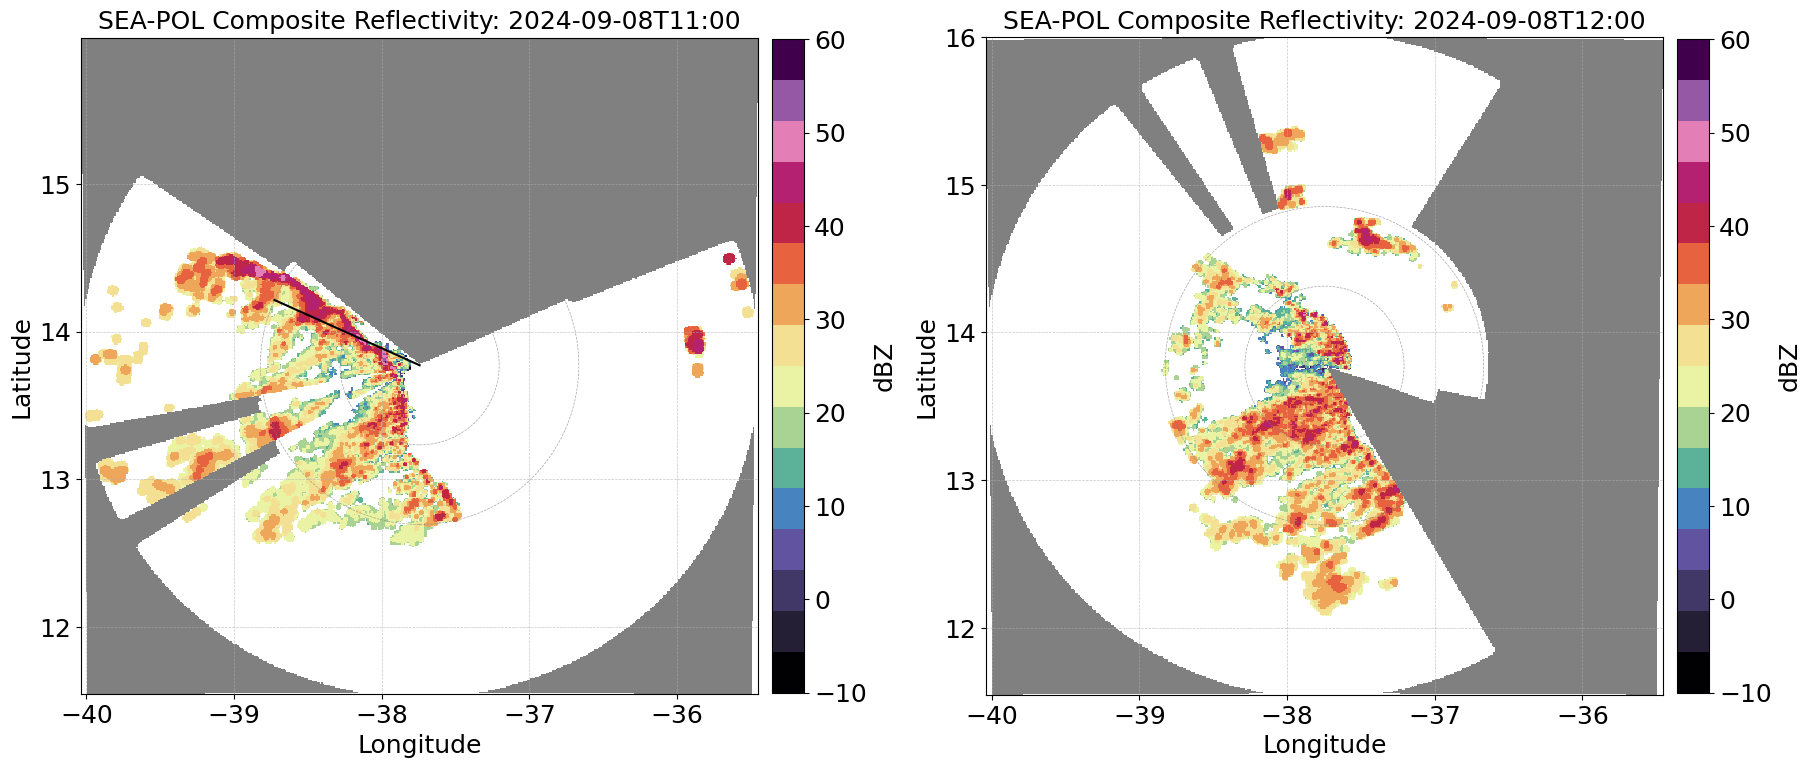

In [10]:
# Make plot
fig, axs = plt.subplots(1,2, figsize=(18, 8),layout="constrained")  # 1 row, 2 column

cax = axs[0].pcolormesh(map1.longitude, map1.latitude, map1, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
axs[0].set_aspect('equal',adjustable='box')
cbar = fig.colorbar(cax, ax=axs[0], orientation='vertical',pad=0.02, shrink=0.83)
cbar.ax.tick_params(labelsize=18)
cbar.set_ticks(np.linspace(-10,60,8))
cbar.ax.set_ylabel('dBZ', fontsize=18)

axs[0].set_title('SEA-POL Composite Reflectivity: ' + str(time_map1),fontsize=18)    
axs[0].set_ylabel('Latitude', fontsize=18)
axs[0].set_xlabel('Longitude',fontsize=18)
axs[0].set_xticks(np.linspace(-40,-36, 5))  # Adjust the number of ticks as needed
axs[0].set_yticks(np.linspace(12, 16, 5))  # Adjust the number of ticks as needed
axs[0].set_xticklabels(axs[0].get_xticklabels(), fontsize=18)
axs[0].set_yticklabels(axs[0].get_yticklabels(), fontsize=18)

cax = axs[1].pcolormesh(map2.longitude, map2.latitude, map2, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
axs[1].set_aspect('equal',adjustable='box')

cbar = fig.colorbar(cax, ax=axs[1], orientation='vertical',pad=0.02, shrink=0.83)
cbar.ax.tick_params(labelsize=18)
cbar.set_ticks(np.linspace(-10,60,8))
cbar.ax.set_ylabel('dBZ', fontsize=18)

axs[1].set_title('SEA-POL Composite Reflectivity: ' + str(time_map2),fontsize=18)    
axs[1].set_ylabel('Latitude', fontsize=18)
axs[1].set_xlabel('Longitude',fontsize=18)
axs[1].set_xticks(np.linspace(-40,-36, 5))  # Adjust the number of ticks as needed
axs[1].set_yticks(np.linspace(12, 16, 5))  # Adjust the number of ticks as needed
axs[1].set_xticklabels(axs[0].get_xticklabels(), fontsize=18)
axs[1].set_yticklabels(axs[0].get_yticklabels(), fontsize=18)

# Add grid lines to the first subplot
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Add grid lines to the second subplot
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Add 120 km circle
axs[0].add_patch(plt.Circle((map1.longitude[245,245], map1.latitude[245,245]), 120/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
axs[1].add_patch(plt.Circle((map2.longitude[245,245], map2.latitude[245,245]), 120/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))

# Add 60 km circle
axs[0].add_patch(plt.Circle((map1.longitude[245,245], map1.latitude[245,245]), 60/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
axs[1].add_patch(plt.Circle((map2.longitude[245,245], map2.latitude[245,245]), 60/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))

# Add azimuth line
# Radar center (latitude and longitude)
center_lat = map1.latitude[245, 245]  # Replace with the radar's latitude
center_lon = map1.longitude[245, 245]  # Replace with the radar's longitude

# Azimuth in degrees
azimuth = rhi.azimuth[index_rhi].values

# Define the radius of the line (e.g., 120 km)
radius_km = 120
radius_deg = radius_km / 111.32  # Convert km to degrees (approximation)

# Calculate the endpoint of the line
end_lat = center_lat + radius_deg * np.cos(np.radians(azimuth))
end_lon = center_lon + radius_deg * np.sin(np.radians(azimuth))

# Draw the line on the first subplot
axs[0].plot([center_lon, end_lon], [center_lat, end_lat], color='black', linestyle='-', linewidth=1.5)


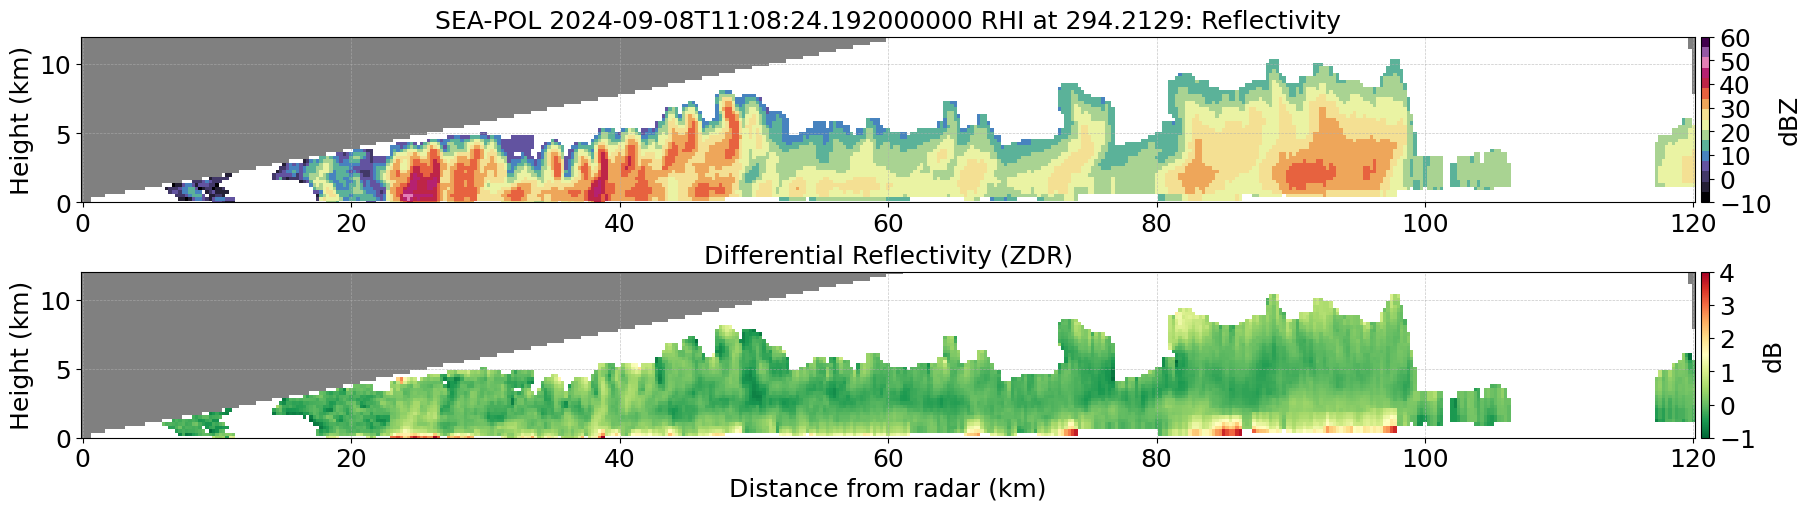

In [16]:
fig, axs = plt.subplots(2,1, figsize=(18, 5),layout="constrained")  # 2 rows, 1 column

#RHI dBZ
cax = axs[0].pcolormesh(rhi.R/1000, rhi.Z/1000, rhi_DBZ, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
cbar = fig.colorbar(cax, ax=axs[0], orientation='vertical',pad=-0.01)
cbar.ax.tick_params(labelsize=18)
cbar.set_ticks(np.linspace(-10,60,8))
cbar.ax.set_ylabel('dBZ', fontsize=18)

axs[0].set_ylim(0,12)
axs[0].set_title('SEA-POL '+str(rhi.start_time[index_rhi].values)+' RHI at '+str(rhi.azimuth[index_rhi].values)+': Reflectivity',fontsize=18)   
axs[0].set_ylabel('Height (km)', fontsize=18)
#axs[0].set_xlabel('Distance from radar (km)',fontsize=18)
axs[0].tick_params(axis='both',labelsize=18)
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

#RHI ZDR
ZDR_cmap = ListedColormap(sns.color_palette("RdYlGn_r", n_colors=256))
ZDR_cmap.set_under(color='white') #set values below vmin to white
ZDR_cmap.set_bad(color='gray') #set missing (NaN) values to gray
cax1 = axs[1].pcolormesh(rhi.R/1000, rhi.Z/1000, rhi_ZDR, cmap=ZDR_cmap, vmin = -1, vmax = 4, shading='auto')
cbar1 = fig.colorbar(cax1, ax=axs[1], orientation='vertical',pad=-0.01)
cbar1.ax.tick_params(labelsize=18)
cbar1.set_ticks(np.linspace(-1,4,6))
#cbar1.ax.set_ylabel('Deg/km', fontsize=18)
cbar1.ax.set_ylabel('dB', fontsize=18)

axs[1].set_ylim(0,12)
#axs[1].set_title('Specific Differential Phase (KDP)',fontsize=18)
axs[1].set_title('Differential Reflectivity (ZDR)',fontsize=18)   
axs[1].set_ylabel('Height (km)', fontsize=18)
axs[1].set_xlabel('Distance from radar (km)',fontsize=18)
axs[1].tick_params(axis='both',labelsize=18)
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


/var/folders/j4/wzfdxl397kl09v45hngwvxd80000gp/T/ipykernel_10526/1984781731.py:30: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cax = axs[0,0].pcolormesh(map1.longitude, map1.latitude, map1, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
/var/folders/j4/wzfdxl397kl09v45hngwvxd80000gp/T/ipykernel_10526/1984781731.py:44: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cax = axs[0,1].pcolormesh(map2.longitude, map2.latitude, map2, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')


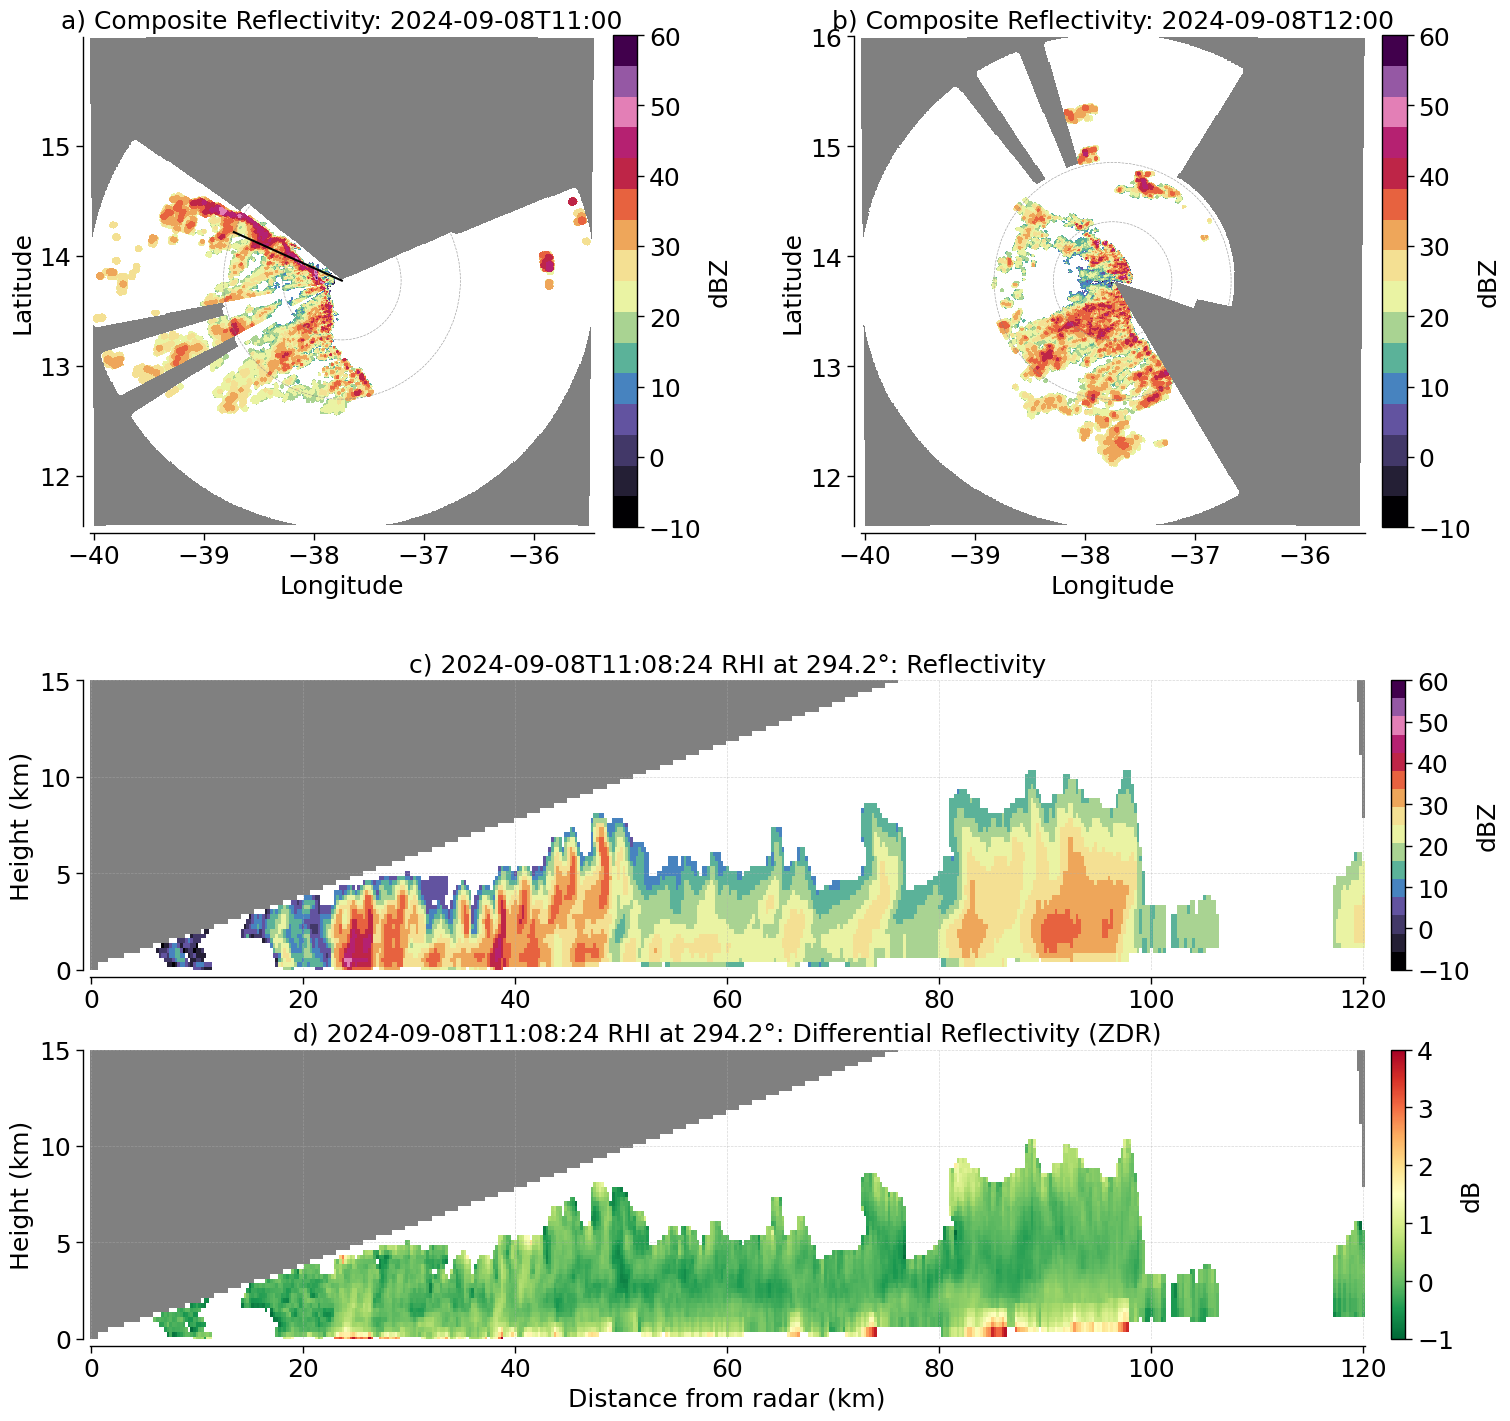

In [83]:
# Make plot
fig, axs = plt.subplots(
    3,
    2,
    figsize=(15, 15),
    layout="constrained",
    gridspec_kw={"height_ratios": [2.5, 1, 1]},
    # 3 rows, 2 columns; rows 2–3 shorter than row 1
 )

# Hide unused axes in the second and third rows
axs[1,1].set_visible(False)
axs[2,1].set_visible(False)

# Remove axs[1,0] and replace it with a new axis that spans all columns in the second row
gs = axs[0,0].get_subplotspec().get_gridspec()
ax_big1 = fig.add_subplot(gs[1, :])

#Remove axs[2,0] and replace it with a new axis that spans all columns in the third row
ax_big2 = fig.add_subplot(gs[2, :])

#Remove the original axes in the second row
for ax in [axs[1,0], axs[1,1]]:
    fig.delaxes(ax)

#Remove the original axes in the third row
for ax in [axs[2,0], axs[2,1]]:
    fig.delaxes(ax)

cax = axs[0,0].pcolormesh(map1.longitude, map1.latitude, map1, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
axs[0,0].set_aspect('equal',adjustable='box')
cbar = fig.colorbar(cax, ax=axs[0,0], orientation='vertical',pad=-0.18,shrink=0.68)
cbar.ax.tick_params(labelsize=18)
cbar.set_ticks(np.linspace(-10,60,8))
cbar.ax.set_ylabel('dBZ', fontsize=18)

axs[0,0].set_title('a) Composite Reflectivity: ' + str(time_map1),fontsize=18)    
axs[0,0].set_ylabel('Latitude', fontsize=18)
axs[0,0].set_xlabel('Longitude',fontsize=18)
axs[0,0].set_xticks(np.linspace(-40,-36, 5))  # Adjust the number of ticks as needed
axs[0,0].set_yticks(np.linspace(12, 16, 5))  # Adjust the number of ticks as needed
axs[0,0].tick_params(axis='both', labelsize=18)

cax = axs[0,1].pcolormesh(map2.longitude, map2.latitude, map2, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
axs[0,1].set_aspect('equal',adjustable='box')

cbar0 = fig.colorbar(cax, ax=axs[0,1], orientation='vertical',pad=-0.01,shrink=0.68)
cbar0.ax.tick_params(labelsize=18)
cbar0.set_ticks(np.linspace(-10,60,8))
cbar0.ax.set_ylabel('dBZ', fontsize=18)

axs[0,1].set_title('b) Composite Reflectivity: ' + str(time_map2),fontsize=18)    
axs[0,1].set_ylabel('Latitude', fontsize=18)
axs[0,1].set_xlabel('Longitude',fontsize=18)
axs[0,1].set_xticks(np.linspace(-40,-36, 5))  # Adjust the number of ticks as needed
axs[0,1].set_yticks(np.linspace(12, 16, 5))  # Adjust the number of ticks as needed
axs[0,1].tick_params(axis='both', labelsize=18)

# Add grid lines to the first subplot
#axs[0,0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Add grid lines to the second subplot
#axs[0,1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Add 120 km circle
axs[0,0].add_patch(plt.Circle((map1.longitude[245,245], map1.latitude[245,245]), 120/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
axs[0,1].add_patch(plt.Circle((map2.longitude[245,245], map2.latitude[245,245]), 120/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))

# Add 60 km circle
axs[0,0].add_patch(plt.Circle((map1.longitude[245,245], map1.latitude[245,245]), 60/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
axs[0,1].add_patch(plt.Circle((map2.longitude[245,245], map2.latitude[245,245]), 60/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))

# Add azimuth line
# Radar center (latitude and longitude)
center_lat = map1.latitude[245, 245]  # Replace with the radar's latitude
center_lon = map1.longitude[245, 245]  # Replace with the radar's longitude

# Azimuth in degrees
azimuth = rhi.azimuth[index_rhi].values

# Define the radius of the line (e.g., 120 km)
radius_km = 120
radius_deg = radius_km / 111.32  # Convert km to degrees (approximation)

# Calculate the endpoint of the line
end_lat = center_lat + radius_deg * np.cos(np.radians(azimuth))
end_lon = center_lon + radius_deg * np.sin(np.radians(azimuth))

# Draw the line on the first subplot
axs[0,0].plot([center_lon, end_lon], [center_lat, end_lat], color='black', linestyle='-', linewidth=1.5)

#RHI dBZ
cax = ax_big1.pcolormesh(rhi.R/1000, rhi.Z/1000, rhi_DBZ, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
cbar1 = fig.colorbar(cax, ax=ax_big1, orientation='vertical',pad=0.003)
cbar1.ax.tick_params(labelsize=18)
cbar1.set_ticks(np.linspace(-10,60,8))
cbar1.ax.set_ylabel('dBZ', fontsize=18)

# Format title values with fewer significant digits
try:
    rhi_time_str = np.datetime_as_string(rhi.start_time[index_rhi].values, unit="s")
except Exception:
    rhi_time_str = str(rhi.start_time[index_rhi].values)
try:
    rhi_az_str = f"{float(rhi.azimuth[index_rhi].values):.1f}"
except Exception:
    rhi_az_str = str(rhi.azimuth[index_rhi].values)

ax_big1.set_ylim(0,15)
ax_big1.set_title('c) ' + rhi_time_str + ' RHI at ' + rhi_az_str + '°: Reflectivity',fontsize=18)   
ax_big1.set_ylabel('Height (km)', fontsize=18)
#ax_big1.set_xlabel('Distance from radar (km)',fontsize=18)
ax_big1.tick_params(axis='both',labelsize=18)
ax_big1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

#RHI ZDR
ZDR_cmap = ListedColormap(sns.color_palette("RdYlGn_r", n_colors=256))
ZDR_cmap.set_under(color='white') #set values below vmin to white
ZDR_cmap.set_bad(color='gray') #set missing (NaN) values to gray
cax1 = ax_big2.pcolormesh(rhi.R/1000, rhi.Z/1000, rhi_ZDR, cmap=ZDR_cmap, vmin = -1, vmax = 4, shading='auto')
cbar2 = fig.colorbar(cax1, ax=ax_big2, orientation='vertical',pad=0.003)
cbar2.ax.tick_params(labelsize=18)
cbar2.set_ticks(np.linspace(-1,4,6))
#cbar2.ax.set_ylabel('Deg/km', fontsize=18)
cbar2.ax.set_ylabel('dB', fontsize=18)

ax_big2.set_ylim(0,15)
#ax_big2.set_title('Specific Differential Phase (KDP)',fontsize=18)
ax_big2.set_title('d) ' + rhi_time_str + ' RHI at ' + rhi_az_str + '°: Differential Reflectivity (ZDR)',fontsize=18)    
ax_big2.set_ylabel('Height (km)', fontsize=18)
ax_big2.set_xlabel('Distance from radar (km)',fontsize=18)
ax_big2.tick_params(axis='both',labelsize=18)
ax_big2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

sns.set_context('paper') 
sns.despine(offset=5)
sns.despine(ax=cbar.ax, left=True, bottom=True, right=True, top=True)
sns.despine(ax=cbar0.ax, left=True, bottom=True, right=True, top=True)
sns.despine(ax=cbar1.ax, left=True, bottom=True, right=True, top=True)
sns.despine(ax=cbar2.ax, left=True, bottom=True, right=True, top=True)
#plt.tight_layout() 

plt.savefig('../figures/Fig_seapol_sept8_4v1.2.pdf',
            format='pdf',bbox_inches='tight',orientation={'landscape'})